Using device: cpu
CelebA direct download failed via torchvision. Switching to simplified Dataset wrapper...
Epoch [1/10], Loss: 9107.5793
Epoch [2/10], Loss: 2628.5071
Epoch [3/10], Loss: 915.2521
Epoch [4/10], Loss: 456.4114
Epoch [5/10], Loss: 325.6385
Epoch [6/10], Loss: 253.2123
Epoch [7/10], Loss: 200.7879
Epoch [8/10], Loss: 168.1093
Epoch [9/10], Loss: 143.5181
Epoch [10/10], Loss: 125.1613


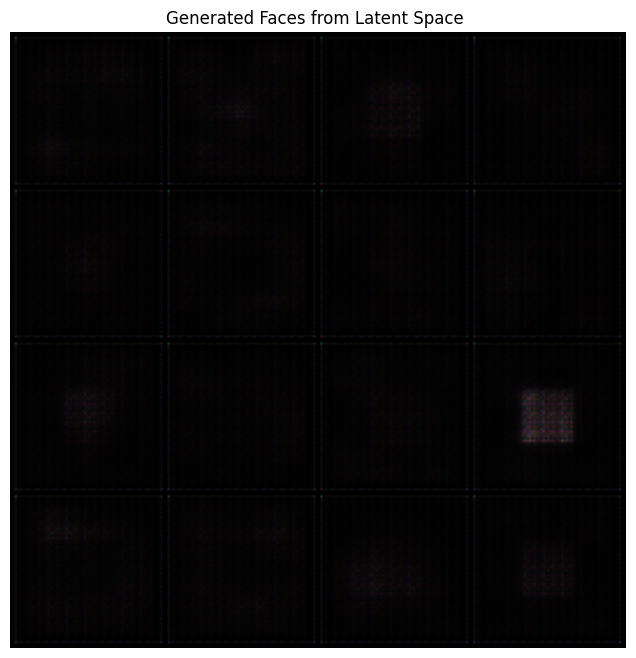

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

image_size = 64
batch_size = 128
latent_dim = 100
num_epochs = 10
learning_rate = 1e-3
num_samples = 500
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

try:
    dataset = datasets.CelebA(root='./data', split='train', download=True, transform=transform)
except Exception as e:
    print("CelebA direct download failed via torchvision. Switching to simplified Dataset wrapper...")
    dataset = datasets.FakeData(size=500, image_size=(3, image_size, image_size), transform=transform)

dataset_subset = Subset(dataset, range(min(num_samples, len(dataset))))
dataloader = DataLoader(
    dataset_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(True)
        )
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 512, 4, 4)
        return self.deconv(x)

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        loss = vae_loss(recon, images, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

model.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = model.decoder(z).cpu()

    generated = generated * 0.5 + 0.5
    grid = torchvision.utils.make_grid(generated, nrow=4)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title("Generated Faces from Latent Space ")
    plt.show()